# 2. Embeddings con sentence-transformers

In [1]:
from sentence_transformers import SentenceTransformer
import torch
import re
import numpy as np
import pandas as pd

In [2]:
# Definimos que use el GPU para esta monda
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando: {device}")

Usando: cuda


In [3]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
print("Modelo cargado. Dimensión de salida:", model.get_embedding_dimension())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo cargado. Dimensión de salida: 384


Cargamos los datasets

In [4]:
conversaciones = pd.read_parquet("../data/dataset_conversaciones/dataset_50k_anonymized.parquet")

In [5]:
conv_full = (conversaciones
    .sort_values(["conv_id", "date"])
    .groupby("conv_id")
    .agg({
        "user_id": "first",
        "input": lambda x: " ".join(x.astype(str)),
        "channel_source": "first"
    })
    .reset_index()
    .rename(columns={"input": "texto_usuario"}))

print(f"Conversaciones reconstruidas: {len(conv_full):,}")
conv_full.head(2)

Conversaciones reconstruidas: 24,119


,conv_id,user_id,texto_usuario,channel_source
0,0000ACA6-AA00-4227-BCE7-5E78C2742D88,USR-12729,Cuál es su tasa de interés para el crédito de ...,1
1,00043647-377f-4528-b2b3-425afd81f6bd,USR-11649,No le deja seleccionar el cobro para hacer la ...,1


In [6]:
def limpiar(t):
    t = str(t).lower()
    t = re.sub(r"\s+", " ", t)
    t = re.sub(r"http\S+", "", t)
    return t.strip()
    
conv_full["texto_limpio"] = conv_full["texto_usuario"].apply(limpiar)

# Filtrar conversaciones muy cortas (ruido)
conv_full = conv_full[conv_full["texto_limpio"].str.len() > 10].reset_index(drop=True)
print(f"Conversaciones tras filtrar: {len(conv_full):,}")

Conversaciones tras filtrar: 23,791


In [7]:
textos = conv_full["texto_limpio"].tolist()

embeddings = model.encode(
    textos,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"Shape embeddings: {embeddings.shape}")
# Esperado: (n_conversaciones, 384)

Batches:   0%|          | 0/372 [00:00<?, ?it/s]

Shape embeddings: (23791, 384)


In [8]:
np.save("embeddings_conv.npy", embeddings)
conv_full[["conv_id", "user_id"]].to_parquet("conv_index.parquet", index=False)
print("Guardado")

Guardado



# 3. Clustering conversacional con BERTopic

## Primera versión

In [9]:
print("Embeddings shape:", embeddings.shape)
print("Conv full:", conv_full.shape)
print("Columnas conv_full:", conv_full.columns.tolist())

Embeddings shape: (23791, 384)
Conv full: (23791, 5)
Columnas conv_full: ['conv_id', 'user_id', 'texto_usuario', 'channel_source', 'texto_limpio']


Cargamos las librerias necesarias

In [10]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

Configurar componentes de BERTopic

In [11]:
# UMAP: reduce dimensiones antes de clusterizar
umap_model = UMAP(
    n_neighbors=15,
    n_components=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# HDBSCAN: clustering por densidad
hdbscan_model = HDBSCAN(
    min_cluster_size=80,        # mínimo de convs para formar cluster
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

print("Modelos configurados")


Modelos configurados


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords en español + algunas específicas del dominio
stopwords_es = [
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las",
    "por", "un", "para", "con", "no", "una", "su", "al", "lo", "como",
    "más", "pero", "sus", "le", "ya", "o", "este", "sí", "porque",
    "esta", "entre", "cuando", "muy", "sin", "sobre", "también", "me",
    "hasta", "hay", "donde", "quien", "desde", "todo", "nos", "durante",
    "todos", "uno", "les", "ni", "contra", "otros", "ese", "eso", "ante",
    "ellos", "e", "esto", "mí", "antes", "algunos", "qué", "unos", "yo",
    "otro", "otras", "otra", "él", "tanto", "esa", "estos", "mucho",
    "quienes", "nada", "muchos", "cual", "poco", "ella", "estar", "estas",
    "algunas", "algo", "nosotros", "mi", "mis", "tú", "te", "ti", "tu",
    "tus", "ellas", "nosotras", "vosotros", "vosotras", "os", "mío",
    "mía", "míos", "mías", "tuyo", "tuya", "tuyos", "tuyas", "suyo",
    "suya", "suyos", "suyas", "nuestro", "nuestra", "nuestros", "nuestras",
    "vuestro", "vuestra", "vuestros", "vuestras", "esos", "esas",
    "hola", "gracias", "buenos", "días", "buenas", "tardes", "noches"
]

vectorizer_model = CountVectorizer(stop_words=stopwords_es, ngram_range=(1, 2))
print("Vectorizer listo")

Vectorizer listo


In [13]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

topics, _ = topic_model.fit_transform(
    documents=conv_full["texto_limpio"].tolist(),
    embeddings=embeddings
)

print(f"\nTópicos detectados: {len(set(topics)) - 1}")  # -1 excluye outliers
print(f"Conversaciones en outliers: {(np.array(topics) == -1).sum():,}")

2026-04-26 05:53:06,543 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 05:54:52,548 - BERTopic - Dimensionality - Completed ✓
2026-04-26 05:54:52,553 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 05:55:02,003 - BERTopic - Cluster - Completed ✓
2026-04-26 05:55:02,027 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 05:55:04,096 - BERTopic - Representation - Completed ✓



Tópicos detectados: 70
Conversaciones en outliers: 7,300


### Tópicos detectados

In [14]:
info = topic_model.get_topic_info()
print(f"Total tópicos: {len(info)}")
info.head(20)

Total tópicos: 71


,Topic,Count,Name,Representation,Representative_Docs
0,-1,7300,-1_si_cuenta_tarjeta_crédito,"[si, cuenta, tarjeta, crédito, puedo, es, teng...","[cancelar tarjeta de crédito, cancelar tarjeta..."
1,0,1492,0_tarjeta_tarjeta física_física_nueva,"[tarjeta, tarjeta física, física, nueva, repos...","[venció mi tarjeta física, solicitar tarjeta f..."
2,1,726,1_aclaración_estado_estado cuenta_apartados,"[aclaración, estado, estado cuenta, apartados,...","[aclaración., donde esta mi estado de cuenta, ..."
3,2,609,2_banco_hey banco_hey_banregio,"[banco, hey banco, hey, banregio, clabe, banco...","[número de hey banco, ya no es banregio hey ba..."
4,3,572,3_enganche_000_auto_meses,"[enganche, 000, auto, meses, crédito auto, 60,...",[crédito auto total 190 000 enganche 40 000 a ...
5,4,565,4_tarjeta crédito_crédito_tarjeta_efectivo,"[tarjeta crédito, crédito, tarjeta, efectivo, ...","[efectivo de mi tarjeta de crédito, puedo reti..."
6,5,443,5_cancelar tarjeta_cancelar_tarjeta crédito_qu...,"[cancelar tarjeta, cancelar, tarjeta crédito, ...","[cancelar mi tarjeta de crédito, hola para can..."
7,6,388,6_app_token_aplicación_celular,"[app, token, aplicación, celular, entrar, móvi...","[token móvil, quiero hacer una transferencia y..."
8,7,381,7_apple_apple pay_pay_tarjeta apple,"[apple, apple pay, pay, tarjeta apple, wallet,...","[como verificar la tarjeta para apple pay, com..."
9,8,376,8_reembolso_dinero_compra_devolución,"[reembolso, dinero, compra, devolución, reflej...",[tengo u. reembolso pendiente y aún no se me v...


In [15]:
for topic_id in info["Topic"].head(10).tolist():
    if topic_id == -1:
        continue
    print(f"\n{'='*60}")
    print(f"TÓPICO {topic_id} · {info[info.Topic==topic_id]['Count'].values[0]} convs")
    print(f"Palabras clave: {[w for w, _ in topic_model.get_topic(topic_id)[:10]]}")
    print(f"\nEjemplo de conversación:")
    ejemplos = [conv_full.iloc[i]['texto_limpio'][:300] 
                for i in range(len(topics)) if topics[i] == topic_id][:2]
    for e in ejemplos:
        print(f"  → {e}")


TÓPICO 0 · 1492 convs
Palabras clave: ['tarjeta', 'tarjeta física', 'física', 'nueva', 'reposición', 'venció', 'solicitar', 'nueva tarjeta', 'costo', 'tarjeta fisica']

Ejemplo de conversación:
  → hola no se si mi tarjeta está prendida
  → hola solo para ver eficaz si mi tarjeta ya quedó activada ok gracias no 👍

TÓPICO 1 · 726 convs
Palabras clave: ['aclaración', 'estado', 'estado cuenta', 'apartados', 'cobro', 'apartado', 'estatus', 'estatus aclaración', 'cajeros', 'folio']

Ejemplo de conversación:
  → necesito meter una aclaración
  → porque al depositarme aparace que no existe

TÓPICO 2 · 609 convs
Palabras clave: ['banco', 'hey banco', 'hey', 'banregio', 'clabe', 'bancos', 'clave', 'independiente', 'cuenta', 'banco es']

Ejemplo de conversación:
  → número hey banco
  → número de hey banco

TÓPICO 3 · 572 convs
Palabras clave: ['enganche', '000', 'auto', 'meses', 'crédito auto', '60', '60 meses', 'mil', 'crédito', '48']

Ejemplo de conversación:
  → crédito auto si 100000 a 24 

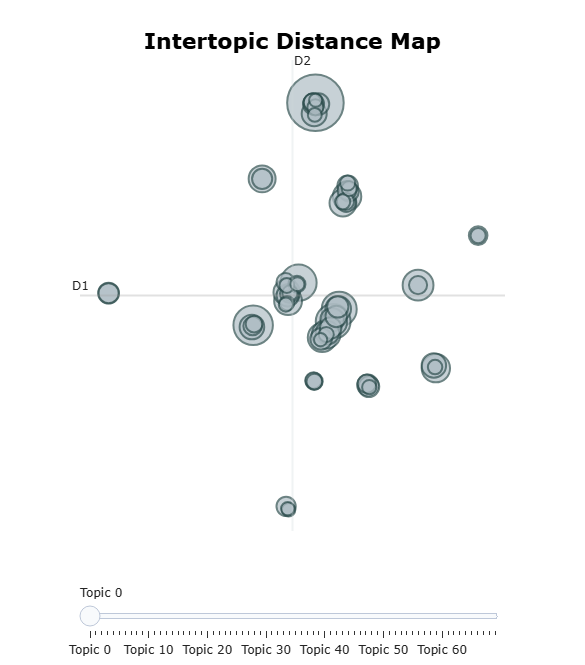

In [16]:
fig = topic_model.visualize_topics()
fig.show()

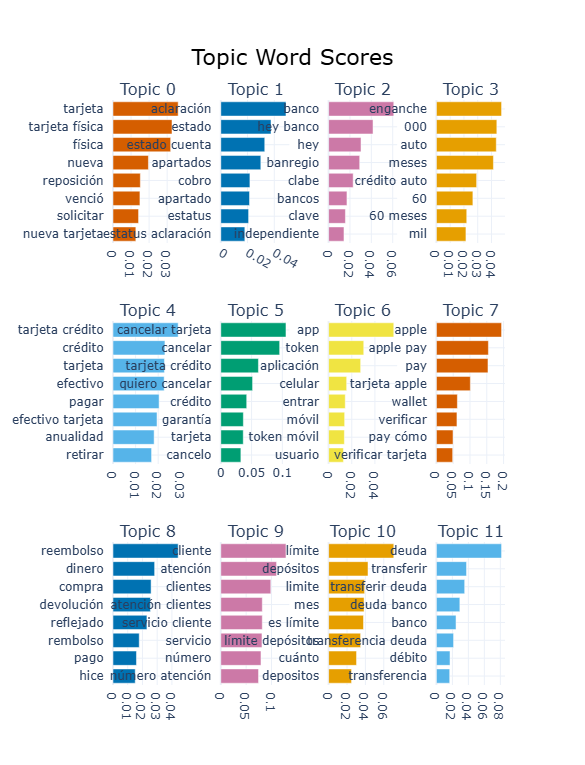

In [17]:
fig = topic_model.visualize_barchart(top_n_topics=12, n_words=8)
fig.show()

In [18]:
conv_full["topic"] = topics
conv_full["topic_name"] = conv_full["topic"].map(
    dict(zip(info["Topic"], info["Name"]))
)

print(conv_full[["conv_id", "user_id", "topic", "topic_name"]].head(10))

                                conv_id    user_id  topic  \
0  0000ACA6-AA00-4227-BCE7-5E78C2742D88  USR-12729     -1   
1  00043647-377f-4528-b2b3-425afd81f6bd  USR-11649     -1   
2  000502c2-288c-41f6-b751-a8b45a376a81  USR-09092     -1   
3  000DD932-B649-41FF-9B2A-EB08B33F5072  USR-10602     -1   
4  00149741-F4D6-4BC9-B8FB-6FFD398FD73F  USR-01560      9   
5  0014FB3D-727F-43B8-9E9C-1F63C0303818  USR-06635     -1   
6  001ea1e9-93aa-4d59-b19f-eb11bb3aa312  USR-00940     11   
7  00221607-cdb2-47f2-a9ac-913d4c7744c6  USR-09344     38   
8  00243113-211B-4123-8C2F-2AEDC69D452E  USR-09850      1   
9  002D9FA0-5064-407C-B4CE-480825090DD5  USR-10380      1   

                                          topic_name  
0                       -1_si_cuenta_tarjeta_crédito  
1                       -1_si_cuenta_tarjeta_crédito  
2                       -1_si_cuenta_tarjeta_crédito  
3                       -1_si_cuenta_tarjeta_crédito  
4      9_cliente_atención_clientes_atención clientes 

In [19]:
# Después de ver los tópicos, decides cuántos perfiles macro quieres
# Por ejemplo: agrupar 30 tópicos en 8 perfiles

# Opción automática: que BERTopic los reduzca por similitud
topic_model.reduce_topics(
    docs=conv_full["texto_limpio"].tolist(),
    nr_topics=10  # número objetivo de perfiles
)

# Re-asignar tópicos
conv_full["perfil_conv"] = topic_model.topics_
info_reducido = topic_model.get_topic_info()
print(info_reducido)

2026-04-26 05:55:38,648 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 05:55:38,737 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 05:55:40,932 - BERTopic - Representation - Completed ✓
2026-04-26 05:55:40,945 - BERTopic - Topic reduction - Reduced number of topics from 71 to 10


   Topic  Count                                             Name  \
0     -1   7300                       -1_tarjeta_si_cuenta_puedo   
1      0  11445                       0_tarjeta_crédito_puedo_si   
2      1   1571                  1_cargo_estado_clabe_aclaración   
3      2   1350                        2_app_apple_pay_apple pay   
4      3   1093                 3_atención_cliente_número_hablar   
5      4    499    4_transferencia_transferencias_recibir_límite   
6      5    188   5_clave_clave interbancaria_contraseña_usuario   
7      6    155            6_codi_pagar codi_codi cómo_pago codi   
8      7    108  7_domicilio_dirección_cambiar_cambiar domicilio   
9      8     82        8_plástico_nuevo_plástico tarjeta_tarjeta   

                                      Representation  \
0  [tarjeta, si, cuenta, puedo, crédito, es, teng...   
1  [tarjeta, crédito, puedo, si, es, quiero, cuen...   
2  [cargo, estado, clabe, aclaración, reconocido,...   
3  [app, apple, pay, apple 

In [20]:
for pid in sorted(set(conv_full["perfil_conv"])):
    if pid == -1:
        continue
    palabras = [w for w, _ in topic_model.get_topic(pid)[:8]]
    n = (conv_full["perfil_conv"] == pid).sum()
    print(f"\nPerfil {pid} · {n} convs")
    print(f"  Palabras: {', '.join(palabras)}")



Perfil 0 · 11445 convs
  Palabras: tarjeta, crédito, puedo, si, es, quiero, cuenta, hey

Perfil 1 · 1571 convs
  Palabras: cargo, estado, clabe, aclaración, reconocido, nip, estado cuenta, movimiento

Perfil 2 · 1350 convs
  Palabras: app, apple, pay, apple pay, aplicación, tarjeta, puedo, cómo

Perfil 3 · 1093 convs
  Palabras: atención, cliente, número, hablar, asesor, clientes, teléfono, atención clientes

Perfil 4 · 499 convs
  Palabras: transferencia, transferencias, recibir, límite, estados unidos, unidos, estados, puedo

Perfil 5 · 188 convs
  Palabras: clave, clave interbancaria, contraseña, usuario, interbancaria, cuenta clave, cuenta, ver

Perfil 6 · 155 convs
  Palabras: codi, pagar codi, codi cómo, pago codi, pagar, qr, codi codi, código

Perfil 7 · 108 convs
  Palabras: domicilio, dirección, cambiar, cambiar domicilio, cambio domicilio, cambio, domicilio cómo, cambiar dirección

Perfil 8 · 82 convs
  Palabras: plástico, nuevo, plástico tarjeta, tarjeta, plastico, plástico

In [21]:
# Backup defensivo
import copy
topic_model_backup = copy.deepcopy(topic_model)
conv_full_backup = conv_full.copy()
print("Backup guardado")

Backup guardado


In [22]:
import copy
topic_model_v1 = copy.deepcopy(topic_model)
print("Backup v1 listo")

Backup v1 listo


## Segunda versión

In [43]:
# Stopwords (las que ya tenías)
stopwords_dominio = stopwords_es + [
    "tarjeta", "tarjetas", "crédito", "credito", "cuenta", "cuentas",
    "puedo", "quiero", "tengo", "necesito", "saber", "puede", "favor",
    "hola", "buenos", "días", "buenas", "tardes", "gracias", "si", "es",
    "hey", "banco", "banregio", "ayuda", "ayudar", "información",
    "cliente", "clientes", "servicio",
    "hacer", "tener", "ser", "estar", "ir", "ver", "dar", "si"
]

vectorizer_model = CountVectorizer(
    stop_words=stopwords_dominio, 
    ngram_range=(1, 2),
    min_df=5
)

umap_model = UMAP(
    n_neighbors=10, n_components=10, min_dist=0.0,
    metric="cosine", random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=20, min_samples=3,
    metric="euclidean", cluster_selection_method="leaf",
    prediction_data=True
)
print("Configuración v2 lista")

Configuración v2 lista


In [44]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

topics, _ = topic_model.fit_transform(
    documents=conv_full["texto_limpio"].tolist(),
    embeddings=embeddings
)

info = topic_model.get_topic_info()
print(f"Total tópicos: {len(info) - 1}")
print(f"Outliers: {(np.array(topics) == -1).sum()}")
print(f"Tópico más grande: {info.iloc[1]['Count']} convs")

2026-04-26 06:28:55,266 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 06:29:31,158 - BERTopic - Dimensionality - Completed ✓
2026-04-26 06:29:31,162 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 06:29:33,247 - BERTopic - Cluster - Completed ✓
2026-04-26 06:29:33,261 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 06:29:34,636 - BERTopic - Representation - Completed ✓


Total tópicos: 372
Outliers: 7606
Tópico más grande: 165 convs


In [45]:
conv_full["topic"] = topics
print(conv_full["topic"].value_counts().head(10))

topic
-1    7606
 0     165
 1     144
 2     136
 3     134
 4     124
 6     122
 5     122
 7     119
 8     117
Name: count, dtype: int64


In [46]:
# Recorrer los 372 tópicos y obtener sus palabras clave
mapeo_data = []
for _, row in info.iterrows():
    tid = row["Topic"]
    if tid == -1:
        continue
    palabras = " ".join([w for w, _ in topic_model.get_topic(tid)[:10]])
    mapeo_data.append({
        "topic_id": tid,
        "count": row["Count"],
        "palabras": palabras
    })

df_mapeo = pd.DataFrame(mapeo_data)
print(f"Tópicos a mapear: {len(df_mapeo)}")
df_mapeo.head(20)

Tópicos a mapear: 372


,topic_id,count,palabras
0,0,165,actualizar versión actualización actualizo cóm...
1,1,144,negocio negocios simple personal meses 60 mese...
2,2,136,préstamo préstamo personal prestamo 12 meses p...
3,3,134,débito debito débito venció débito cómo adicio...
4,4,124,cancelar garantizada cancelar garantía garantí...
5,5,122,sat qr link pago pagos captura pago aclaración...
6,6,122,aumento aumentar línea cómo aumentar aumentar ...
7,7,119,parámetros agregar wallet ticket rechaza walle...
8,8,117,factura liquide auto liquidar automotriz origi...
9,9,115,reembolso rembolso ve reflejado ve reflejado d...


In [51]:
def clasificar_perfil(palabras):
    p = palabras.lower()
    
    # ===== NUEVAS REGLAS DE ESTA RONDA =====
    if any(k in p for k in ["acciones", "acción", "vender", "comprar accion", "bolsa", "trading"]):
        return "Inversión bursátil"
    if any(k in p for k in ["tipo cambio", "dólares", "dolares", "dólar", "fx"]):
        return "Tipo de cambio / divisas"
    if any(k in p for k in ["saldo aparece", "saldo disponible", "consultar saldo", "veo saldo", "saldo"]):
        return "Consulta de saldo"
    if any(k in p for k in ["límite diario", "límite tope", "cuál límite", "cuánto límite", "monto total", "límite manejar"]):
        return "Consulta de límites"
    if any(k in p for k in ["mercado libre", "rechazada", "rechazaron", "fondos insuficientes"]):
        return "Compras rechazadas"
    if any(k in p for k in ["cuánto tarda", "tiempo tarda", "tarda caer", "cuanto tarda"]):
        return "Tiempos de procesamiento"
    if any(k in p for k in ["entregada", "entregaron", "entrega", "recibí", "recibido", "envío"]):
        return "Entrega de tarjeta"
    if any(k in p for k in ["usuario nombre", "cambiar usuario", "editar usuario", "alta usuario"]):
        return "Cambio de usuario"
    if any(k in p for k in ["números mismo", "cambian numeración", "nueva numeración"]):
        return "Cambio de números de tarjeta"
    if any(k in p for k in ["contrato", "carátula", "caratula"]):
        return "Contrato / carátula"
    if any(k in p for k in ["beneficiarios", "beneficiario"]):
        return "Beneficiarios"
    
    # ===== REGLAS RONDA ANTERIOR =====
    if any(k in p for k in ["referido", "referidos", "bono", "recompensa"]):
        return "Referidos / bonos"
    if any(k in p for k in ["pro cómo", "convierto pro", "soy pro", "activar pro", "hey pro"]):
        return "Hey Pro / suscripción"
    if any(k in p for k in ["menores", "menor", "hija", "hijo", "cuenta menor"]):
        return "Cuenta para menores"
    if any(k in p for k in ["moto", "motocicleta"]):
        return "Crédito moto"
    if any(k in p for k in ["perdí", "perdi", "perdió", "extraviada", "extravió", "clonaron", "robaron", "robada"]):
        return "Tarjeta perdida / robada"
    if any(k in p for k in ["estado cuenta", "estado mes", "descargar estado", "estado febrero", "estado enero", "obtener estado", "sacar estado"]):
        return "Estado de cuenta"
    if any(k in p for k in ["fecha límite", "fecha pago", "fecha corte", "día pago"]):
        return "Fechas de pago / corte"
    if any(k in p for k in ["solicitar", "solicito"]):
        return "Solicitud de productos"
    if any(k in p for k in ["eliminar", "borrar", "quitar", "darla baja", "doy baja", "baja"]):
        return "Eliminar / dar de baja"
    if any(k in p for k in ["activar", "activo", "activé"]):
        return "Activación"
    if any(k in p for k in ["portabilidad nómina", "portabilidad nomina", "potabilidad"]):
        return "Portabilidad de nómina"
    
    # ===== REGLAS ORIGINALES =====
    if any(k in p for k in ["préstamo personal", "prestamo", "préstamo"]):
        return "Crédito personal"
    if any(k in p for k in ["negocio", "negocios", "pyme"]):
        return "Crédito negocio"
    if any(k in p for k in ["auto", "automotriz", "factura", "vehículo"]):
        return "Crédito auto"
    if any(k in p for k in ["aumento", "aumentar línea", "línea crédito"]):
        return "Aumento de línea"
    if any(k in p for k in ["meses intereses", "msi", "diferir", "diferido"]):
        return "MSI / pagos diferidos"
    if any(k in p for k in ["garantizada", "garantía"]):
        return "Tarjeta garantizada"
    if any(k in p for k in ["cancelar", "cancelo", "cancelación"]):
        return "Cancelaciones"
    if any(k in p for k in ["bloqueada", "bloqueo", "desbloquear"]):
        return "Tarjeta bloqueada"
    if any(k in p for k in ["plástico", "reposición", "vencer", "venció", "física"]):
        return "Reposición de plástico"
    if any(k in p for k in ["transferencia", "transferir", "spei", "estados unidos", "extranjero", "remesa"]):
        return "Transferencias"
    if any(k in p for k in ["clabe", "clave interbancaria"]):
        return "CLABE / datos bancarios"
    if any(k in p for k in ["cargo reconocido", "reconozco", "aclaración", "movimiento", "reembolso", "rembolso", "devolución", "disputa"]):
        return "Disputas y aclaraciones"
    if any(k in p for k in ["apple pay", "google pay", "wallet", "apple", "samsung pay"]):
        return "Pagos digitales (wallet)"
    if any(k in p for k in ["codi", "qr"]):
        return "CoDi / QR"
    if any(k in p for k in ["actualizar", "actualización", "versión", "app", "aplicación"]):
        return "Problemas de app"
    if any(k in p for k in ["token", "clave", "contraseña", "incorrecto", "nip"]):
        return "Autenticación / token"
    if any(k in p for k in ["atención", "asesor", "humano", "ejecutivo", "hablar", "teléfono"]):
        return "Atención humana"
    if any(k in p for k in ["validación", "biométrica", "comprobante", "verificación", "selfie"]):
        return "Validación / onboarding"
    if any(k in p for k in ["domicilio", "dirección", "datos", "correo", "notificaciones"]):
        return "Datos personales / config"
    if any(k in p for k in ["depósito", "depositar", "efectivo", "oxxo", "farmacia"]):
        return "Depósitos en efectivo"
    if any(k in p for k in ["retiro", "cajero", "atm"]):
        return "Retiros / cajeros"
    if any(k in p for k in ["inversión", "ahorro", "rendimiento", "gat"]):
        return "Inversión"
    if any(k in p for k in ["anualidad", "recompensas", "beneficios", "promociones", "promoción", "cashback"]):
        return "Beneficios y recompensas"
    if any(k in p for k in ["seguro", "póliza", "vida", "compras"]):
        return "Seguros"
    if any(k in p for k in ["terminal", "tpv", "punto venta", "cobro"]):
        return "Negocios / terminal"
    if any(k in p for k in ["tiempo aire", "recarga", "telcel", "celular"]):
        return "Tiempo aire / recargas"
    if any(k in p for k in ["sat", "impuestos", "hacienda", "gobierno"]):
        return "Pagos a gobierno / SAT"
    if any(k in p for k in ["pal norte", "fan shop", "edición", "rayados"]):
        return "Tarjeta Pal Norte / Fan Shop"
    
    return "Otros"
# Aplicar
df_mapeo["perfil_macro"] = df_mapeo["palabras"].apply(clasificar_perfil)

# Ver resultado de la clasificación
print(df_mapeo["perfil_macro"].value_counts())
print(f"\nTópicos en 'Otros': {(df_mapeo['perfil_macro'] == 'Otros').sum()}")

perfil_macro
Transferencias                  30
Atención humana                 24
Disputas y aclaraciones         21
Solicitud de productos          18
Crédito auto                    17
Cancelaciones                   16
Problemas de app                15
Otros                           15
Depósitos en efectivo           14
Consulta de saldo               14
Autenticación / token           14
Eliminar / dar de baja          12
Reposición de plástico          12
Tarjeta garantizada              8
Activación                       8
Retiros / cajeros                8
Pagos digitales (wallet)         7
Referidos / bonos                7
CLABE / datos bancarios          7
Entrega de tarjeta               7
MSI / pagos diferidos            6
Contrato / carátula              6
Beneficios y recompensas         6
Tiempos de procesamiento         6
Cuenta para menores              5
Tarjeta bloqueada                5
Tarjeta perdida / robada         5
Consulta de límites              5
Datos p

In [52]:
otros = df_mapeo[df_mapeo["perfil_macro"] == "Otros"].sort_values("count", ascending=False)
print(f"Tópicos en 'Otros' ({len(otros)}):\n")
for _, row in otros.head(20).iterrows():
    print(f"  T{row['topic_id']:>3} · {row['count']:>4} convs · {row['palabras'][:120]}")

Tópicos en 'Otros' (15):

  T 69 ·   60 convs · personal línea blanco página personal dónde linea nesecito cuento estatus válido
  T 77 ·   57 convs · veo aparece aparece aparece adeudo dice pendiente apartado tenía tenia pendiente dónde malo
  T 79 ·   56 convs · número marcar marcar referencia número referencia número puedes número numero número número banxico dame número
  T149 ·   41 convs · perfil menú perfil transaccional validar transaccional está opción sección dónde está principal encuentra
  T188 ·   35 convs · recibir mes mes mes cuánto pago mes cuánto recibir pagar mes mes cuanto cuanto recibir mensualmente recibir
  T224 ·   31 convs · pertenece monterrey oficiales compañía algun costo tiene algun heybanco dices oficial cuales son
  T255 ·   28 convs · contactar comunico comunicarme contacto cómo cómo comunicarme llamar contacto disponible opción cómo llamar llegó cargo
  T279 ·   26 convs · veo número encuentro número número dónde número numero dónde encuentro numero núme

In [53]:
# Distribución por número de conversaciones (no de tópicos)
conv_full["perfil_macro"] = conv_full["topic"].map(
    dict(zip(df_mapeo["topic_id"], df_mapeo["perfil_macro"]))
)
conv_full.loc[conv_full["topic"] == -1, "perfil_macro"] = "Sin clasificar"

print("Distribución por # de conversaciones:")
print(conv_full["perfil_macro"].value_counts().head(20))
print(f"\nTotal convs: {len(conv_full):,}")
print(f"% Sin clasificar: {(conv_full['perfil_macro']=='Sin clasificar').mean():.1%}")
print(f"% Otros: {(conv_full['perfil_macro']=='Otros').mean():.1%}")

Distribución por # de conversaciones:
perfil_macro
Sin clasificar              7606
Transferencias              1169
Atención humana             1167
Solicitud de productos      1096
Disputas y aclaraciones      854
Crédito auto                 809
Problemas de app             734
Consulta de saldo            544
Reposición de plástico       536
Cancelaciones                529
Depósitos en efectivo        505
Otros                        496
Activación                   496
Autenticación / token        495
Tarjeta garantizada          449
Eliminar / dar de baja       447
Pagos digitales (wallet)     430
MSI / pagos diferidos        373
CLABE / datos bancarios      328
Referidos / bonos            327
Name: count, dtype: int64

Total convs: 23,791
% Sin clasificar: 32.0%
% Otros: 2.1%


In [54]:
def consolidar_perfil(perfil):
    """Agrupa los 50 perfiles en ~22 macro-perfiles accionables."""
    
    productos_credito = {
        "Crédito auto", "Crédito personal", "Crédito negocio", 
        "Crédito moto", "Aumento de línea", "MSI / pagos diferidos"
    }
    tarjeta_gestion = {
        "Reposición de plástico", "Activación", "Tarjeta bloqueada",
        "Tarjeta perdida / robada", "Cancelaciones", 
        "Cambio de números de tarjeta", "Entrega de tarjeta"
    }
    inversiones = {"Inversión", "Inversión bursátil"}
    disputas = {"Disputas y aclaraciones", "Compras rechazadas"}
    saldo_limites = {"Consulta de saldo", "Consulta de límites", "Estado de cuenta"}
    hey_pro = {"Hey Pro / suscripción", "Referidos / bonos", 
               "Beneficios y recompensas"}
    onboarding = {"Validación / onboarding", "Cuenta para menores", 
                  "Cambio de usuario", "Portabilidad de nómina"}
    pagos_digitales = {"Pagos digitales (wallet)", "CoDi / QR", 
                       "Tipo de cambio / divisas"}
    config = {"Datos personales / config", "Fechas de pago / corte",
              "Beneficiarios", "Contrato / carátula"}
    
    if perfil in productos_credito: return "Productos de crédito"
    if perfil in tarjeta_gestion:   return "Gestión de tarjeta"
    if perfil in inversiones:        return "Inversión"
    if perfil in disputas:           return "Disputas y problemas con cargos"
    if perfil in saldo_limites:      return "Saldo y consultas"
    if perfil in hey_pro:            return "Hey Pro y beneficios"
    if perfil in onboarding:         return "Onboarding y datos personales"
    if perfil in pagos_digitales:    return "Pagos digitales"
    if perfil in config:             return "Configuración / contrato"
    
    # Quedan solos por ser claros y grandes
    if perfil in {"Transferencias", "Atención humana", "Solicitud de productos",
                  "Problemas de app", "Depósitos en efectivo", "Eliminar / dar de baja",
                  "Tarjeta garantizada", "Retiros / cajeros", "CLABE / datos bancarios",
                  "Autenticación / token", "Tiempos de procesamiento", "Negocios / terminal",
                  "Seguros", "Sin clasificar"}:
        return perfil
    
    if perfil == "Pagos a gobierno / SAT":      return "Pagos a gobierno"
    if perfil == "Tarjeta Pal Norte / Fan Shop": return "Tarjeta Pal Norte"
    if perfil == "Tiempo aire / recargas":       return "Tiempo aire"
    
    return "Otros"

conv_full["perfil_final"] = conv_full["perfil_macro"].apply(consolidar_perfil)

print("Distribución consolidada:")
print(conv_full["perfil_final"].value_counts())
print(f"\nTotal perfiles únicos: {conv_full['perfil_final'].nunique()}")

Distribución consolidada:
perfil_final
Sin clasificar                     7606
Gestión de tarjeta                 2300
Productos de crédito               1787
Transferencias                     1169
Atención humana                    1167
Solicitud de productos             1096
Disputas y problemas con cargos     913
Saldo y consultas                   908
Problemas de app                    734
Configuración / contrato            715
Hey Pro y beneficios                622
Pagos digitales                     591
Onboarding y datos personales       573
Depósitos en efectivo               505
Otros                               496
Autenticación / token               495
Tarjeta garantizada                 449
Eliminar / dar de baja              447
CLABE / datos bancarios             328
Retiros / cajeros                   242
Tiempos de procesamiento            186
Inversión                           134
Negocios / terminal                 118
Tarjeta Pal Norte                    78
P

In [55]:
# Perfil dominante por usuario
perfil_dom = (conv_full
    .groupby("user_id")["perfil_final"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"perfil_final": "perfil_dominante"}))

# Distribución de perfiles por usuario (% en cada perfil)
perfil_dist = (conv_full
    .groupby(["user_id", "perfil_final"])
    .size()
    .unstack(fill_value=0))
perfil_dist = perfil_dist.div(perfil_dist.sum(axis=1), axis=0)
perfil_dist.columns = [f"pct_{c.replace(' ', '_').replace('/', '').replace('  ', '_').lower()}" 
                       for c in perfil_dist.columns]
perfil_dist = perfil_dist.reset_index()

# Diversidad
perfil_div = (conv_full
    .groupby("user_id")["perfil_final"]
    .nunique()
    .reset_index()
    .rename(columns={"perfil_final": "n_perfiles_tocados"}))

# # conversaciones
n_conv = (conv_full.groupby("user_id").size()
    .reset_index(name="n_conversaciones"))

# % por canal (asumiendo "2" es voz)
canal = (conv_full.groupby("user_id")["channel_source"]
    .agg(lambda x: (x.astype(str) == "2").mean())
    .reset_index()
    .rename(columns={"channel_source": "pct_voz"}))

# Unir todo
features_conv = (perfil_dom
    .merge(n_conv, on="user_id")
    .merge(perfil_div, on="user_id")
    .merge(canal, on="user_id")
    .merge(perfil_dist, on="user_id"))

print(f"Shape: {features_conv.shape}")
print(f"Usuarios con perfil: {features_conv['user_id'].nunique():,}")
print(f"\nDistribución de perfil dominante por usuario:")
print(features_conv["perfil_dominante"].value_counts())
features_conv.head(3)

Shape: (14928, 32)
Usuarios con perfil: 14,928

Distribución de perfil dominante por usuario:
perfil_dominante
Sin clasificar                     5048
Gestión de tarjeta                 1404
Productos de crédito               1248
Transferencias                      720
Atención humana                     687
Solicitud de productos              680
Saldo y consultas                   514
Disputas y problemas con cargos     508
Problemas de app                    469
Configuración / contrato            447
Hey Pro y beneficios                392
Onboarding y datos personales       367
Pagos digitales                     353
Depósitos en efectivo               305
Otros                               288
Tarjeta garantizada                 273
Eliminar / dar de baja              271
Autenticación / token               263
CLABE / datos bancarios             191
Retiros / cajeros                   140
Tiempos de procesamiento             87
Inversión                            75
Negocios 

,user_id,perfil_dominante,n_conversaciones,n_perfiles_tocados,pct_voz,pct_atención_humana,pct_autenticación__token,pct_clabe__datos_bancarios,pct_configuración__contrato,pct_depósitos_en_efectivo,...,pct_retiros__cajeros,pct_saldo_y_consultas,pct_seguros,pct_sin_clasificar,pct_solicitud_de_productos,pct_tarjeta_pal_norte,pct_tarjeta_garantizada,pct_tiempo_aire,pct_tiempos_de_procesamiento,pct_transferencias
0,USR-00001,Hey Pro y beneficios,1,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,USR-00002,Configuración / contrato,1,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,USR-00003,Atención humana,1,1,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
conv_full.to_parquet("conv_full_perfiles_finales.parquet", index=False)
features_conv.to_parquet("features_conv.parquet", index=False)
df_mapeo.to_csv("mapeo_topics_a_perfiles.csv", index=False)
print("✓ Guardado")
print(f"  - conv_full_perfiles_finales.parquet: {len(conv_full):,} filas")
print(f"  - features_conv.parquet: {len(features_conv):,} usuarios")

✓ Guardado
  - conv_full_perfiles_finales.parquet: 23,791 filas
  - features_conv.parquet: 14,928 usuarios


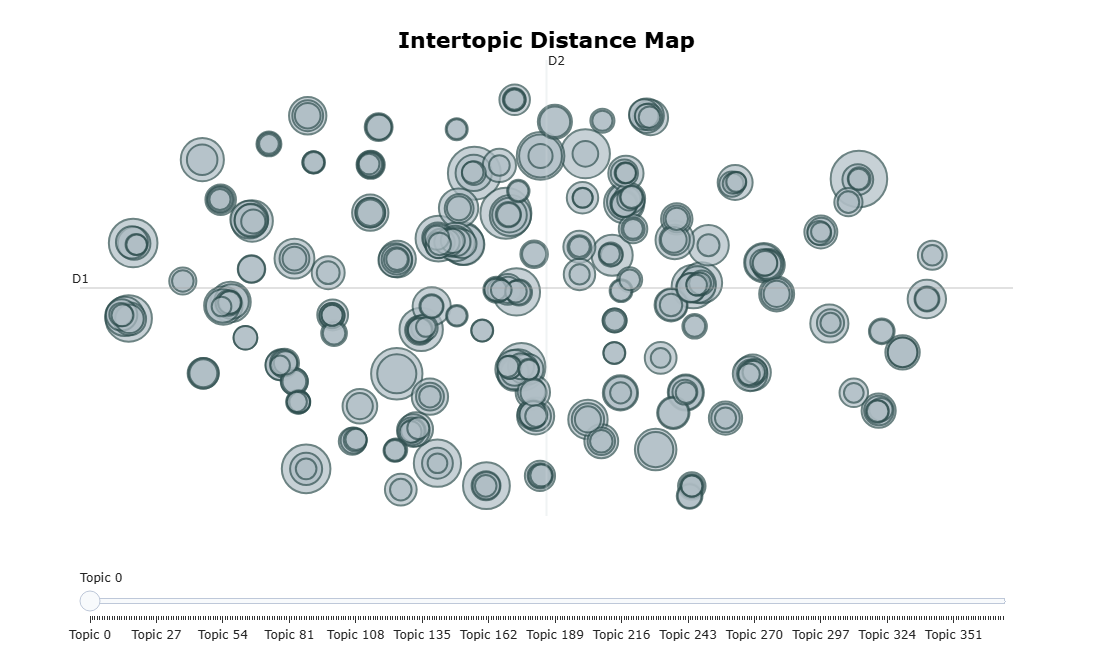

In [57]:
fig = topic_model.visualize_topics()
fig.show()

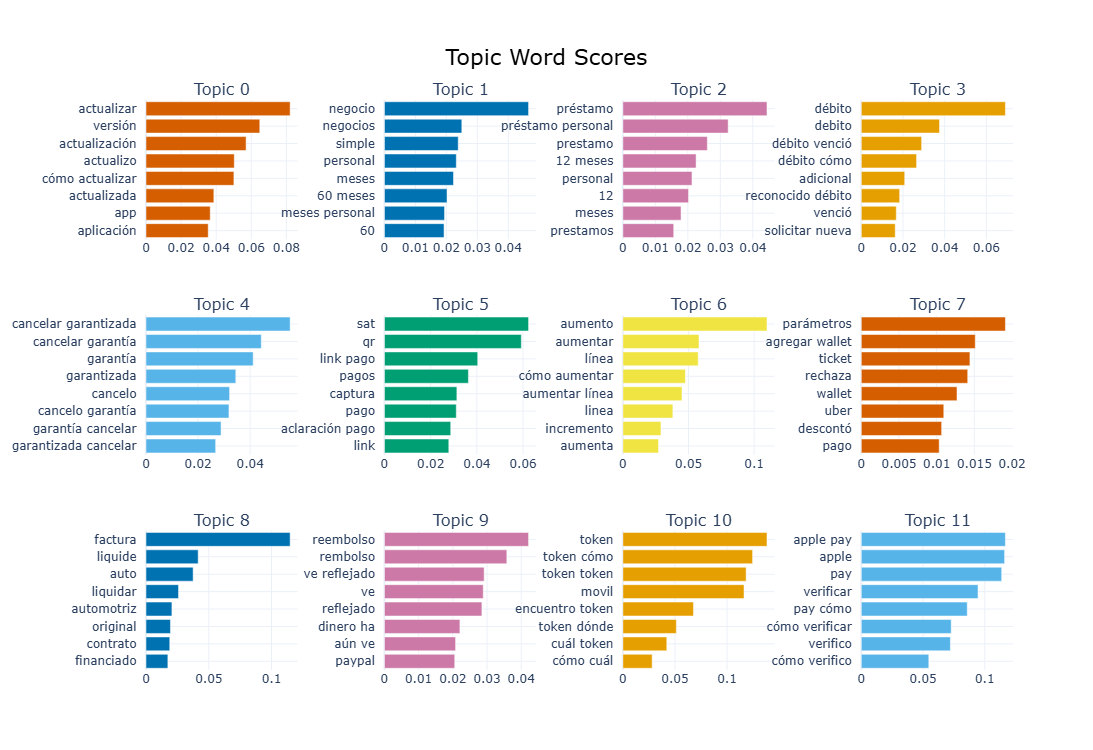

In [58]:
fig = topic_model.visualize_barchart(top_n_topics=12, n_words=8)
fig.show()